In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from IPython.display import Image, display

c:\Users\Deven\multi_tool_ai_agent\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class State(TypedDict):
  # add_messages merges new messages into the list
    # instead of overwriting — this is the LangGraph way
    messages: Annotated[list[AnyMessage], add_messages]

In [3]:
!pip install langchain-tavily

In [4]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ['Tavily_API_Key']=os.getenv('Tavily_API_Key')
#(os.getenv("GROQ_API_KEY"))
#print(os.getenv("Tavily_API_Key"))

In [39]:
from langchain.tools import tool
from langchain_tavily import TavilySearch
import os

tavily = TavilySearch(
    tavily_api_key=os.getenv("TAVILY_API_KEY"),
    max_results=2
)

@tool
def web_search(query: str) -> str:
    """Search real-time information"""
    results = tavily.invoke(query)
    return str(results)   # 🔥 VERY IMPORTANT

In [26]:
!pip install sympy

In [27]:
from langchain.tools import tool
import sympy as sp
import math
import re
from sympy.parsing.sympy_parser import (
    parse_expr, standard_transformations, implicit_multiplication_application
)

# Enable implicit multiplication like x(x+1)
transformations = standard_transformations + (implicit_multiplication_application,)


# -------- HELPER FUNCTION --------
def extract_value(text, key):
    match = re.search(rf"{key}=([-+]?\d*\.?\d+)", text)
    return float(match.group(1)) if match else None


@tool
def advanced_calculator(query: str) -> str:
    """
    Advanced math solver:
    - Algebra
    - Calculus
    - Numerical methods
    - Probability
    - Differential equations
    """

    try:
        query = query.replace("^", "**").strip().lower()

        # ---------------- NORMAL DISTRIBUTION ----------------
        if "normal probability" in query:
            mean = extract_value(query, "mean")
            std = extract_value(query, "std")
            x_val = extract_value(query, "x")

            if None in (mean, std, x_val):
                return "Error: Provide mean, std, and x"

            z = (x_val - mean) / std
            prob = 0.5 * (1 + math.erf(z / math.sqrt(2)))

            return f"Normal Probability: {prob}"

        # ---------------- BINOMIAL ----------------
        elif "binomial" in query:
            n = int(extract_value(query, "n"))
            p = extract_value(query, "p")
            k = int(extract_value(query, "k"))

            if None in (n, p, k):
                return "Error: Provide n, p, k"

            prob = math.comb(n, k) * (p**k) * ((1-p)**(n-k))
            return f"Binomial Probability: {prob}"

        # ---------------- NEWTON METHOD ----------------
        elif "newton" in query:
            expr = query.split("newton")[1].split("initial")[0].strip()
            x0 = extract_value(query, "initial")

            x = sp.symbols('x')
            f = parse_expr(expr, transformations=transformations)
            f_prime = sp.diff(f, x)

            for _ in range(10):
                x0 = x0 - float(f.subs(x, x0)) / float(f_prime.subs(x, x0))

            return f"Newton Root: {x0}"

        # ---------------- BISECTION METHOD ----------------
        elif "bisection" in query:
            expr = query.split("bisection")[1].split("a=")[0].strip()
            a = extract_value(query, "a")
            b = extract_value(query, "b")

            x = sp.symbols('x')
            f = sp.lambdify(x, parse_expr(expr, transformations=transformations))

            for _ in range(20):
                c = (a + b) / 2
                if f(a) * f(c) < 0:
                    b = c
                else:
                    a = c

            return f"Bisection Root: {(a+b)/2}"

        # ---------------- DIFFERENTIAL EQUATIONS ----------------
        elif "dsolve" in query:
            x = sp.symbols('x')
            y = sp.Function('y')

            expr = query.replace("dsolve", "").strip()
            eq = parse_expr(expr, transformations=transformations)

            return f"ODE Solution: {sp.dsolve(eq)}"

        # ---------------- LIMIT ----------------
        elif "limit" in query:
            # Example: limit(sin(x)/x, x, 0)
            expr = query.replace("limit", "").strip("() ")
            parts = expr.split(",")

            f = parse_expr(parts[0], transformations=transformations)
            var = sp.symbols(parts[1].strip())
            point = parse_expr(parts[2].strip())

            return f"Limit: {sp.limit(f, var, point)}"

        # ---------------- SOLVE ----------------
        elif "solve" in query:
            expr = query.replace("solve", "").strip()

            if "=" in expr:
                left, right = expr.split("=")
                eq = sp.Eq(
                    parse_expr(left, transformations=transformations),
                    parse_expr(right, transformations=transformations)
                )
            else:
                eq = parse_expr(expr, transformations=transformations)

            symbols = list(eq.free_symbols)
            sol = sp.solve(eq, symbols[0]) if symbols else sp.solve(eq)

            return f"Solution: {sol}"

        # ---------------- DERIVATIVE ----------------
        elif "derivative" in query:
            expr = query.replace("derivative of", "").replace("derivative(", "").replace(")", "").strip()
            expr = parse_expr(expr, transformations=transformations)

            var = list(expr.free_symbols)[0]
            return f"Derivative: {sp.diff(expr, var)}"

        # ---------------- INTEGRATION ----------------
        elif "integrate" in query:
            expr = query.replace("integrate", "").strip()
            expr = parse_expr(expr, transformations=transformations)

            var = list(expr.free_symbols)[0]
            return f"Integral: {sp.integrate(expr, var)}"

        # ---------------- GENERAL ----------------
        else:
            expr = parse_expr(query, transformations=transformations)
            return f"Result: {expr.evalf()}"

    except Exception as e:
        return f"Error: {str(e)}"

In [28]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)

def llm_to_math(query: str):
    prompt = f"""
Convert the user question into a valid SymPy-compatible math expression.

STRICT RULES:
- Output ONLY expression
- No explanation
- No text
- Use 'solve' for equations
- Use 'derivative of'
- Use 'integrate'
- Convert % to decimal

Examples:
"What is 20% of 500?" → 0.2 * 500
"Solve x^2 - 4 = 0" → solve x^2 - 4 = 0
"Derivative of x^2" → derivative of x^2
"Integrate x^2" → integrate x^2

Question: {query}
"""

    response = llm.invoke(prompt)
    return response.content.strip()

In [29]:
def clean_expression(expr: str):
    expr = expr.split("=")[0]  # remove unwanted = parts
    return expr.strip()

In [30]:
def full_math_solver(query: str):
    math_expression = llm_to_math(query)
    math_expression = clean_expression(math_expression)

    print("Converted Expression:", math_expression)  # DEBUG

    return advanced_calculator.invoke(math_expression)

In [31]:
print(full_math_solver("What is 25% of 800?"))
print("_"*100)
print(full_math_solver("Solve x^2 - 9 = 0"))
print("_"*100)
print(full_math_solver("Derivative of x^3 + 2x"))
print("_"*100)
print(full_math_solver("Integrate x^2 + 3x"))
print("_"*100)
print(full_math_solver("Solve x(x+5) = 84"))

Converted Expression: 0.25 * 800
Result: 200.000000000000
____________________________________________________________________________________________________
Converted Expression: solve(x**2 - 9)
Solution: [-3, 3]
____________________________________________________________________________________________________
Converted Expression: derivative(x**3 + 2*x)
Derivative: 3*x**2 + 2
____________________________________________________________________________________________________
Converted Expression: integrate(x**2 + 3*x)
Integral: x**3/3 + 3*x**2/2
____________________________________________________________________________________________________
Converted Expression: solve(x*(x+5) - 84)
Solution: [-12, 7]


In [ ]:
tools = [advanced_calculator, web_search]

In [33]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0
)

In [34]:
llm_with_tools=llm.bind_tools(tools=tools)

In [41]:
from langchain_core.messages import SystemMessage, AIMessage

def tool_calling_llm(state: State):
    # 🔥 ALWAYS define inside function
    system = SystemMessage(content="""
You are an AI assistant.

STRICT RULES:
- Use web_search for real-world info
- Use advanced_calculator for math
- DO NOT hallucinate
- Always give clean final answers
""")

    messages = state.get("messages", [])

    if not messages:
        return {"messages": []}

    # 🔥 LIMIT CONTEXT
    context = [system] + messages[-4:]

    response = llm_with_tools.invoke(context)

    return {
        "messages": [response]
    }

In [42]:

# 🔹 Create graph builder
builder = StateGraph(State)

# 🔹 Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", tool_node)

# 🔹 Entry point
builder.add_edge(START, "tool_calling_llm")

# 🔹 Conditional routing
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END   # ✅ CORRECT
    }
)

# 🔹 Loop back after tool execution
builder.add_edge("tools", "tool_calling_llm")

# 🔹 Compile graph
graph = builder.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


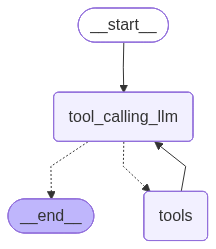

In [43]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
messages=graph.invoke({"messages":"what is the cost of gold"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the cost of gold
================================== Ai Message ==================================
Tool Calls:
  web_search (3eke8s7sf)
 Call ID: 3eke8s7sf
  Args:
    query: current gold price
================================= Tool Message =================================
Name: web_search

[{"title": "Gold Price Today | Gold Spot Price Charts | APMEX", "url": "https://www.apmex.com/gold-price", "content": "This follows a trend of new record-setting highs for gold in recent history. The current bull market began when a new high was established on August 7, 2020, and gold passed $2,074 per ounce. This milestone was primarily driven by the economic uncertainty caused by the COVID-19 pandemic, low interest rates, a weakening U.S. dollar, and increased demand for safe-haven assets. Just a few short years later, another new high was achieved on May 4, 2023, when gold hit $2,080.72. This was sparked by 

In [45]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({
    "messages": [HumanMessage(content="Hi i am deva can you tell about the todays wether condition in bangalore with todays date")]
})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi i am deva can you tell about the todays wether condition in bangalore with todays date
================================== Ai Message ==================================
Tool Calls:
  web_search (s1qcdt9rh)
 Call ID: s1qcdt9rh
  Args:
    query: Bangalore weather today April 19, 2024
================================= Tool Message =================================
Name: web_search

[{"title": "Bengaluru hits 38.2 degrees Celsius, rain forecast in city on April 19", "url": "https://www.newindianexpress.com/states/karnataka/2024/Apr/19/bengaluru-hits-382-degrees-celsius-rain-forecast-in-city-on-april-19", "content": "Rainfall has also been forecast over Dakshina Kannada, Udupi, Uttara Kannada, Belagavi, Dharwad, Gadag, Haveri, Chamarajanagar, Chikkaballapur, Chikkamagaluru, Chitradurga, Davanagere, Hassan, Kodagu, Kolar, Mandya, Mysuru, Ramanagara, Shivamogga, Tumakuru and Vijayanagara.\n\nFollow The New In

In [46]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({
    "messages": [HumanMessage(content="tell me about baahubali and calcutate the derivative of 2x")]
})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me about baahubali and calcutate the derivative of 2x
================================== Ai Message ==================================
Tool Calls:
  web_search (ys0a090s2)
 Call ID: ys0a090s2
  Args:
    query: Baahubali movie information
  advanced_calculator (f4e00x60h)
 Call ID: f4e00x60h
  Args:
    query: derivative of 2x
================================= Tool Message =================================
Name: web_search

[{"title": "Everything You Need to Know About Baahubali: The Epic Movie (2025)", "url": "https://www.movieinsider.com/m24708/baahubali-the-epic", "content": "Movie Insider\nMovie Insider\n\n# Baahubali: The Epic Movie\n\nEditor Amy Renner photo  By Amy Renner    Oct. 21, 2025\n\nEditor Amy Renner photo\nBaahubali: The Epic Movie Poster\nWatch Baahubali: The Epic Official Trailer — Official Trailer\n\nWho's Involved:\n\nPrabhas, Sathyaraj, Ramya Krishnan, Tamannaah Bhatia, Nassar, 

In [50]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({
    "messages": [HumanMessage(content="give me the list of job opening in bangalore for aiml role and calcualt the derivative of ")]
})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the list of job opening in bangalore for aiml role and calcualt the derivative of 
================================== Ai Message ==================================
Tool Calls:
  web_search (hwqqhznwy)
 Call ID: hwqqhznwy
  Args:
    query: job openings in Bangalore for AI/ML role
  advanced_calculator (1vr2jfa11)
 Call ID: 1vr2jfa11
  Args:
    query: derivative of x^2 + 3x - 4
================================= Tool Message =================================
Name: web_search

[{"title": "50+ Artificial Intelligence (AI) Jobs in Bangalore (Bengaluru) - Cutshort", "url": "https://cutshort.io/jobs/artificial-intelligence-ai-jobs-in-bangalore-bengaluru", "content": "Qualifications & Skills:\n\n   8–10 years of experience in software engineering, ML systems, or scalable AI product builds.\n   Proven success leading cross-functional AI/ML and full-stack teams through 0→1 and scale-up phases.\n   Expertis